# Gradient Descent

경사하강법(Gradient Descent)은 **손실 함수가 작아지는 방향으로 파라미터를 반복해서 수정하는 학습 방법**이다.

<img src="https://d.pr/i/0vERpX+" alt="경사하강법" width="500">

| 항목 | 설명 |
|---|---|
| 목적 | 손실 함수가 가장 작아지는 파라미터를 찾는 것 |
| 방식 | 손실 함수의 기울기, 즉 gradient의 반대 방향으로 파라미터를 업데이트함 |
| 반복 | 한 번에 정답을 찾는 것이 아니라 여러 번 조금씩 수정함 |

## 선형 회귀에서 예측식

$$
\hat{y} = w_0 + w_1x
$$

- `x`: 입력 feature 값.
- `y`: 실제 정답 값.
- `ŷ`: 모델이 예측한 값.
- `w0`: 절편. 그래프를 위아래로 이동시키는 값.
- `w1`: 기울기. x가 증가할 때 y가 얼마나 증가하는지 정하는 값.
- 모델 학습: 데이터에 잘 맞는 `w0`, `w1`을 찾는 과정.

## 손실 함수가 필요한 이유

모델이 잘 맞는지 판단하려면 "잘 맞음"을 숫자로 바꿔야 함.  
이 숫자가  **손실 함수(Loss Function)** 이다.

```text
오차 = 실제값 - 예측값
손실 함수 = 여러 데이터의 오차를 하나의 숫자로 요약한 값
```

손실 값이 크면 모델이 많이 틀린 것이고, 손실 값이 작으면 모델이 데이터에 더 잘 맞는 것이다.

## RSS와 MSE

회귀에서 자주 사용하는 손실 계산 방식에는 RSS와 MSE가 있다.

| 용어 | 의미 | 특징 |
|---|---|---|
| RSS | 오차 제곱합 | 모든 오차 제곱을 더함 |
| MSE | 평균 제곱 오차 | RSS를 데이터 개수 `N`으로 나눈 값 |

RSS는 다음과 같음.

$$
RSS = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

MSE는 다음과 같음.

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

 `np.mean(diff ** 2)`를 사용하므로 MSE 기준으로 설명함.

## 편미분이 필요한 이유

경사하강법은 `w0`, `w1`을 조금씩 수정해야 함.  
그런데 아무 방향으로 움직이면 안 되고, **손실이 줄어드는 방향**으로 움직여야 함.

이때 필요한 것이 편미분이다.

| 용어 | 의미                                            |
|---|-----------------------------------------------|
| 미분 | 한 변수가 조금 변할 때 결과가 어떻게 변하는지 보는 것,변수가 하나일 때 변화율 |
| 편미분 | 여러 변수 중 하나만 움직였을 때 결과가 어떻게 변하는지 보는 것, 변수가 여러 개일 때, 하나만 골라서 보는 변화율|
| gradient | 각 파라미터에 대한 편미분 값을 모아 놓은 기울기 정보                |

현재 손실 함수는 `w0`, `w1` 두 값에 의해 달라짐.  
그래서 각각 따로 질문해야 함.

```text
w0를 조금 바꾸면 MSE가 어떻게 변하는가?
w1을 조금 바꾸면 MSE가 어떻게 변하는가?
```

이 질문의 답이 `w0_grad`, `w1_grad`이다.

## 업데이트 식

$$
w := w - \eta \cdot \frac{dL(w)}{dw}
$$

- `w`: 수정할 파라미터.
- `L(w)`: 손실 함수.
- `dL(w) / dw`: 현재 위치에서 손실이 증가하는 방향의 기울기.
- `η`: 학습률. 한 번에 움직이는 크기.
- `-`를 붙이는 이유는 손실이 증가하는 방향의 반대로 가야 손실이 줄어들기 때문이다.

## 수업용 한 문장

경사하강법은 손실 함수를 보고 `w0`, `w1`을 어느 방향으로 고쳐야 할지 계산한 뒤, 그 반대 방향으로 조금씩 움직이면서 오차를 줄이는 방법이다.


In [2]:
# 초기 세팅용 import 구문입니다. 먼저 실행한 뒤 실습 코드를 작성합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 예제 데이터 생성

경사하강법을 이해하기 위해 정답 식이 있는 가짜 회귀 데이터를 생성함.

```text
y = 6 * X + 4 + noise
```

여기서 `6`은 실제 기울기, `4`는 실제 절편.  
모델은 이 값을 모르는 상태에서 시작하고, 경사하강법으로 `w1 ≈ 6`, `w0 ≈ 4`에 가까운 값을 찾아가야 함.

- 진행 순서
    - 처음에는 아무것도 모르는 상태에서 `w0=0`, `w1=0`으로 시작함.
    - 예측값과 실제값의 차이를 손실로 계산함.
    - 손실이 줄어드는 방향으로 `w0`, `w1`을 반복 수정함.


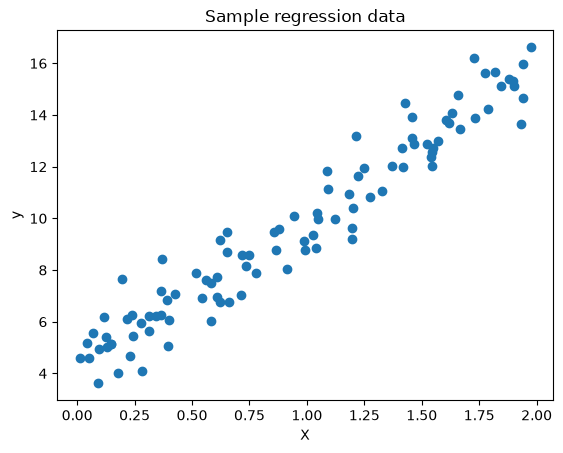

In [3]:
# 정답 식이 있는 가짜 회귀 데이터를 생성하고 산점도로 확인함.
np.random.seed(42)

# np.random.rand(100, 1): 0~1 사이 난수 100개를 2차원 배열로 생성함.
# 2를 곱해 X 범위를 0~2 사이로 넓힘.
X = 2 * np.random.rand(100, 1)

# 실제 데이터 생성에 사용한 정답 기울기와 절편.
# 모델은 이 값을 모른다고 가정하고, 경사하강법으로 비슷한 값을 찾아가야 함.
true_w = 6
true_b = 4

# y = 6X + 4 형태의 선형 관계를 만듦.
y = true_w * X + true_b

# 실제 데이터처럼 완벽한 직선이 아니라 약간 흔들리도록 정규분포 노이즈를 추가함.
y += np.random.randn(100, 1)

# 산점도를 보면 X가 커질수록 y도 증가하는 선형 경향을 확인할 수 있음.
plt.scatter(X, y)
plt.title('Sample regression data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

## 오차, 손실 함수, 파라미터 업데이트 1회

경사하강법 전체를 반복하기 전에, 한 번의 업데이트가 어떻게 일어나는지 직접 계산함.

```text
1. 현재 w0, w1로 y_pred 계산
2. 실제값 y와 예측값 y_pred의 차이 diff 계산
3. diff를 이용해 손실 함수 MSE 계산
4. MSE를 w0, w1로 각각 편미분해 gradient 계산
5. gradient의 반대 방향으로 w0, w1 업데이트
```

처음에는 `w0=0`, `w1=0`에서 시작하므로 예측선이 데이터와 잘 맞지 않음.  
업데이트를 한 번 수행하면 손실이 아주 조금 줄어드는 방향으로 값이 이동함.

## 이 코드에서 쓰는 공식

예측식은 다음과 같음.

$$
\hat{y}_i = w_0 + w_1x_i
$$

코드에서는 오차를 다음처럼 둠.

$$
diff_i = y_i - \hat{y}_i
$$

MSE는 다음과 같음.

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}diff_i^2
$$

MSE를 `w0`로 편미분하면 다음과 같음.

$$
\frac{\partial MSE}{\partial w_0} = -\frac{2}{N}\sum_{i=1}^{N}diff_i
$$

MSE를 `w1`로 편미분하면 다음과 같음.

$$
\frac{\partial MSE}{\partial w_1} = -\frac{2}{N}\sum_{i=1}^{N}x_i \cdot diff_i
$$

위 공식을 코드의 변환하면 다음과 같음.

```python
w0_grad = (-2 / N) * np.sum(diff)
w1_grad = (-2 / N) * np.dot(X.T, diff)
```

이후 학습률 `lr`을 곱해서 w0, w1을 업데이트함.

```python
w0 -= lr * w0_grad
w1 -= lr * w1_grad
```


In [6]:
# 손실함수(MSE)를 계산하고, 경사하강법 업데이트 1회를 직접 수행

# w0(절편), w1(가중치, 기울기) 1회차 값 설정
# 처음에는 학습을 안한상태 -> 전부 0
w0 = np.zeros((1, 1))
w1 = np.zeros((1, 1))

# 현재 w0, w1을 이용해서 예측치를 계산
# 보통 점곱(dot product, 내적) 을 말해.
# 파이썬/데이터분석/머신러닝에서 자주 나오는 이유는 “여러 값을 각각 곱해서 더하는 계산”임
y_pred_before = w0 + np.dot(X, w1)

# diff : 오차 (diff가 크면 모델이 많이 틀렸다, 정확하지 않다)
diff = y - y_pred_before

# MSE(오차 제곱의 평균)
mse = np.mean(diff**2)

# N : 전체 데이터의 개수
# lr : Learning Rate(학습률), gradient 방향으로 한 번에 얼마나 이동할지 정하는 값

N = len(X)
lr = 0.01

# w0_grad : MSE를 w0 방향으로 편미분한 값
w0_grad = (-2 / N) * np.sum(diff)

# w1_grad : MSE를 w1 방향으로 편미분한 값
w1_grad = (-2 / N) * np.dot(X.T, diff)

w0 -= lr * w0_grad
w1 -= lr * w1_grad


# 업데이트 후 예측값과 손실을 다시 계산함.
y_pred_after = w0 + np.dot(X, w1)
mse_after = np.mean((y - y_pred_after) ** 2)

print(f'업데이트 전 MSE: {mse:.4f}')
print(f'업데이트 후 MSE: {mse_after:.4f}')
print(f'업데이트 후 w0: {w0.item():.4f}')
print(f'업데이트 후 w1: {w1.item():.4f}')

업데이트 전 MSE: 105.4255
업데이트 후 MSE: 96.9677
업데이트 후 w0: 0.1928
업데이트 후 w1: 0.2218


## Batch Gradient Descent

Batch Gradient Descent는 **전체 훈련 데이터**를 사용해 한 번의 업데이트 방향을 계산함.

한 번 업데이트할 때 전체 데이터를 모두 보기 때문에, 기울기 방향이 비교적 안정적.
다만 데이터가 아주 많으면 매번 전체 데이터를 계산해야 해서 느릴 수 있음.

| 구분 | 의미 |
|---|---|
| 사용하는 데이터 | 전체 데이터 |
| 장점 | 업데이트 방향이 안정적 |
| 단점 | 데이터가 많으면 계산량이 큼 |
| 수업 포인트 | 손실이 반복마다 점점 줄어드는지 확인함 |


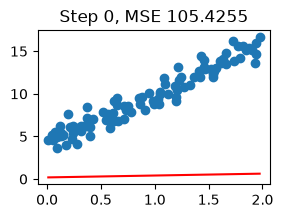

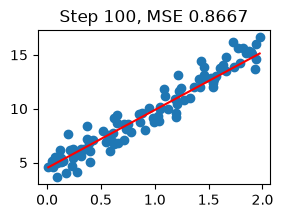

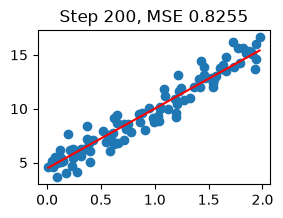

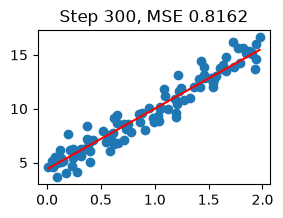

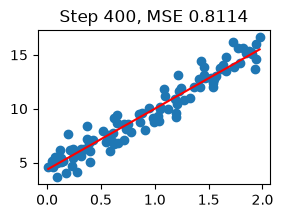

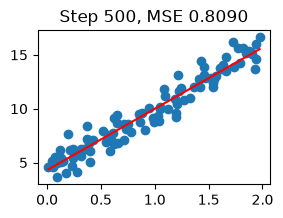

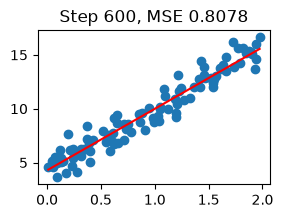

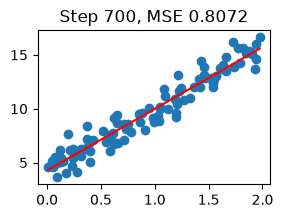

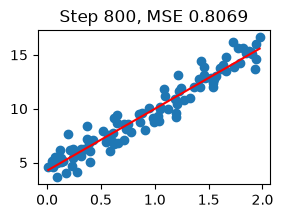

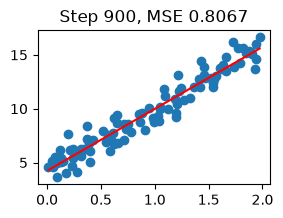

학습된 w0 : 4.2316
학습된 w1 : 5.7555
최종 MSE : 0.8067


[np.float64(105.4254548648602),
 np.float64(96.96774154128815),
 np.float64(89.19418099333605),
 np.float64(82.04942868118034),
 np.float64(75.48261718024631),
 np.float64(69.44699400333137),
 np.float64(63.899588721240626),
 np.float64(58.800907011821735),
 np.float64(54.11464945901542),
 np.float64(49.80745309976066),
 np.float64(45.84865387855794),
 np.float64(42.21006831835834),
 np.float64(38.865792853266235),
 np.float64(35.79201939429708),
 np.float64(32.96686581501105),
 np.float64(30.37022015007376),
 np.float64(27.983597397431854),
 np.float64(25.79000790452918),
 np.float64(23.773836401468607),
 np.float64(21.920730819830602),
 np.float64(20.217500105534473),
 np.float64(18.652020298165816),
 np.float64(17.213148208051244),
 np.float64(15.890642076457963),
 np.float64(14.675088654015669),
 np.float64(13.557836178156329),
 np.float64(12.530932772368578),
 np.float64(11.587069828667115),
 np.float64(10.719529970158007),
 np.float64(9.922139223191401),
 np.float64(9.18922305856

In [11]:
def gradient_descent(X, y, n_iter=1000, lr=0.01):
    # w0는 절편, w1은 기울기. 0에서 시작해 반복 업데이트함.
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))
    N = len(X)
    loss_history = [] #  반복별 MSE를 저장하기 위한 list

    # 회귀선을 부드럽게 그리기 위한 X 좌표.
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

    for i in range(n_iter):
        # 현재 w0, w1로 예측값을 계산함.
        y_pred = w0 + np.dot(X, w1)

        # 실제값과 예측값의 차이를 계산함.
        diff = y - y_pred

        # 현재 손실을 기록함. 손실이 줄어드는지 확인하기 위한 값.
        mse = np.mean(diff ** 2)
        loss_history.append(mse)

        # 전체 데이터를 사용해 MSE의 기울기를 계산함.
        w0_grad = (-2 / N) * np.sum(diff)
        w1_grad = (-2 / N) * np.dot(X.T, diff)

        # 오차가 줄어드는 방향으로 파라미터를 업데이트함.
        w0 -= lr * w0_grad
        w1 -= lr * w1_grad

        # 100번마다 현재 회귀선을 그려 학습 진행 상황을 눈으로 확인함.
        if i % 100 == 0:
            plt.figure(figsize=(3, 2))
            plt.scatter(X, y)
            plt.plot(x_line, w0.item() + w1.item() * x_line, color='r')
            plt.title(f'Step {i}, MSE {mse:.4f}')
            plt.show()

    return w0, w1, loss_history

w0, w1, loss_history = gradient_descent(X, y)

print(f'학습된 w0 : {w0.item():.4f}')
print(f'학습된 w1 : {w1.item():.4f}')
print(f'최종 MSE : {loss_history[-1]:.4f}')

loss_history

# w0. w1 반복 업데이트
# 회귀선이 데이터에 가까워지고, 손실 값이 내려가고 있음을 확인

## 학습된 `w0`, `w1`로 예측선을 만들고, 실제 데이터와 얼마나 가까운지 확인해보기.

1. 회귀선 그래프: 빨간 선이 실제 데이터의 경향을 잘 따라가는지 확인함.
2. 손실 그래프: 반복이 진행될수록 MSE가 줄어드는지 확인함.

손실 그래프가 빠르게 내려가다가 점점 완만해지면, 모델이 더 이상 크게 고칠 부분이 줄어드는 것으로 해석할 수 있음.


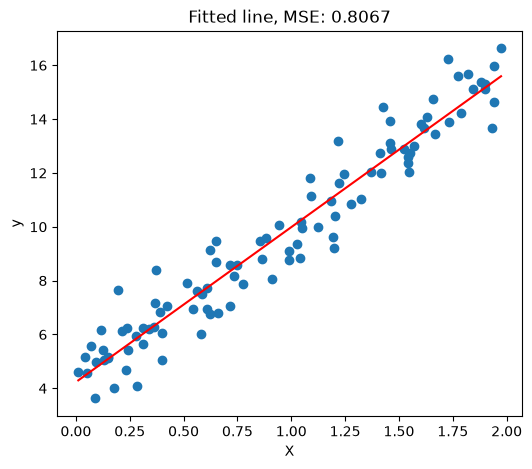

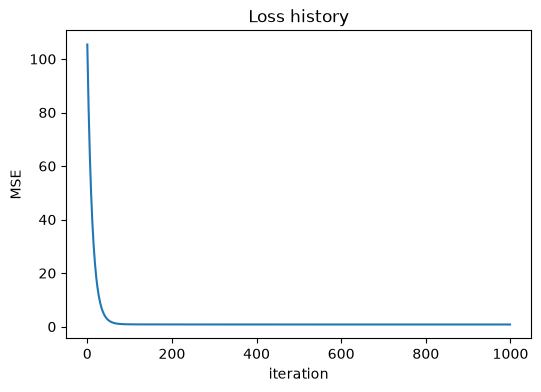

최종 MSE: 0.8067


In [12]:
from sklearn.metrics import mean_squared_error

# 학습된 w0, w1로 전체 X에 대한 예측값을 계산함.
y_pred = w0.item() + w1.item() * X

# mean_squared_error(): 실제값과 예측값 차이를 제곱한 뒤 평균냄.
# 값이 작을수록 예측선이 데이터에 더 가깝다는 뜻.
mse = mean_squared_error(y, y_pred)

# 회귀선을 부드럽게 그리기 위한 X 좌표.
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = w0.item() + w1.item() * x_line

plt.figure(figsize=(6, 5))
plt.scatter(X, y)
plt.plot(x_line, y_line, color='r')
plt.title(f'Fitted line, MSE: {mse:.4f}')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Loss history')
plt.xlabel('iteration')
plt.ylabel('MSE')
plt.show()

print(f'최종 MSE: {mse:.4f}')

## Mini-batch Gradient Descent

Mini-batch 방식은 전체 데이터가 아니라 **일부 데이터 묶음(batch)** 만 사용해 한 번의 업데이트를 수행함.

전체 데이터를 매번 모두 사용하지 않기 때문에 Batch 방식보다 계산량이 적음.  
데이터 1개만 사용하는 SGD(확률적 경사하강법) 방식보다는 방향이 덜 흔들림.
그래서 실제 딥러닝 학습에서는 Mini-batch 방식이 가장 많이 사용됨.

| 구분 | 의미 |
|---|---|
| 사용하는 데이터 | 일부 데이터 묶음 |
| 장점 | Batch보다 빠르고, SGD보다 안정적 |
| 단점 | batch 선택에 따라 손실이 약간 흔들릴 수 있음 |

주의할 점은 `batch_size`가 업데이트 방향의 안정성에 영향을 준다는 점.  
`batch_size`가 작으면 빠르지만 흔들림이 커지고, 크면 안정적이지만 계산량이 늘어남.


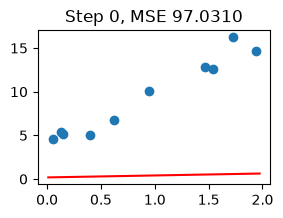

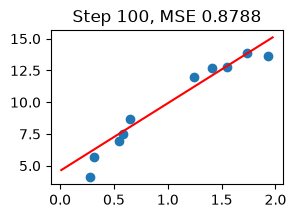

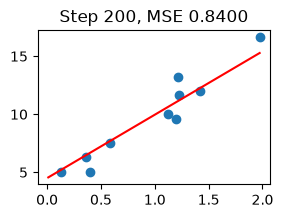

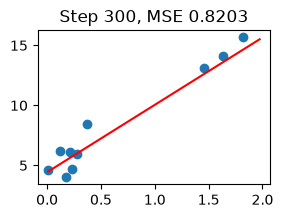

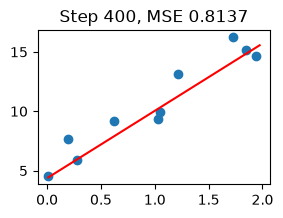

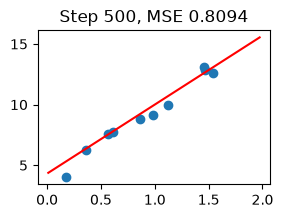

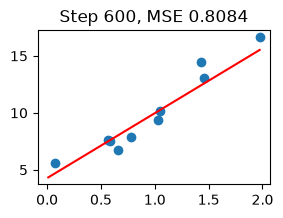

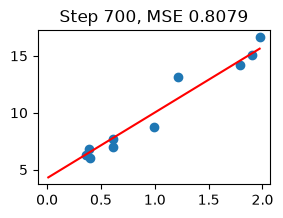

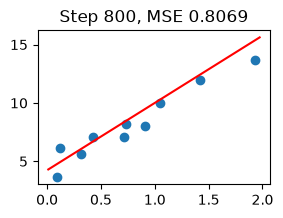

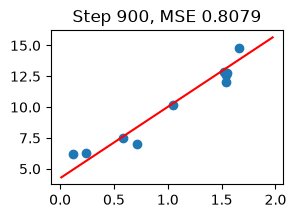

Mini-Batch GD w0 : 4.2077
Mini-Batch GD w1 : 5.7789
Mini-Batch GD 최종 MSE : 0.8066


In [14]:
def mini_batch_gradient_descent(X, y, batch_size=10, n_iter=1000, lr=0.01):
    N = len(X)

    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    loss_history = []

    # x_line: 회귀선을 부드럽게 그리기 위한 X 좌표.
    # X의 최솟값부터 최댓값까지 균등 간격으로 100개 값을 생성함.
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

    for i in range(n_iter):
        # permutation
        # np.random.permutation(N): 0부터 N-1까지의 인덱스를 무작위 순서로 섞음.
        # [:batch_size]: 섞인 인덱스 중 앞에서 batch_size개만 선택함.
        # 즉, 전체 100개 중 일부 데이터만 뽑아 이번 업데이트에 사용함.
        indices = np.random.permutation(N)[:batch_size]

        X_batch = X[indices]
        y_batch = y[indices]

        # batch_n: 실제 선택된 mini-batch 데이터 개수.
        batch_n = len(X_batch)

        # 선택된 mini-batch에 대해서만 예측값을 계산함.
        # 예측식: y_pred_batch = w0 + w1 * X_batch
        y_pred_batch = w0 + np.dot(X_batch, w1)

        # diff_batch: mini-batch 안에서의 실제값과 예측값 차이.
        diff_batch = y_batch - y_pred_batch

        # mini-batch 기준 MSE의 기울기를 계산함.
        w0_grad = (-2 / batch_n) * np.sum(diff_batch)

        # w1은 X에 곱해지는 기울기이므로, 각 오차에 X값을 곱해 반영함.
        w1_grad = (-2 / batch_n) * np.dot(X_batch.T, diff_batch)

        # 파라미터 업데이트.
        w0 -= lr * w0_grad
        w1 -= lr * w1_grad

        # 업데이트된 w0, w1이 전체 데이터에 대해 얼마나 좋아졌는지 확인함.
        y_pred_all = w0 + np.dot(X, w1)
        mse = np.mean((y - y_pred_all) ** 2)
        loss_history.append(mse)

        # 100번마다 현재 mini-batch와 회귀선을 시각화함.
        # 파란 점은 이번 업데이트에 사용된 일부 데이터이고, 빨간 선은 현재 w0, w1로 만든 회귀선.
        if i % 100 == 0:
            plt.figure(figsize=(3, 2))
            plt.scatter(X_batch, y_batch)
            plt.plot(x_line, w0.item() + w1.item() * x_line, color='r')
            plt.title(f'Step {i}, MSE {mse:.4f}')
            plt.show()

    return w0, w1, loss_history

w0, w1, loss_history = mini_batch_gradient_descent(X, y)

print(f'Mini-Batch GD w0 : {w0.item():.4f}')
print(f'Mini-Batch GD w1 : {w1.item():.4f}')
print(f'Mini-Batch GD 최종 MSE : {loss_history[-1]:.4f}')

# Mini-Batch GD는 마지막 MSE가 무조건 최소값이 아니다
# --> 랜덤으로 데이터 일부만 가지고 학습을 하다보니 오차가 발생할 수 밖에 없음

## Stochastic Gradient Descent (확률적 경사 하강법)

Stochastic Gradient Descent는 매번 **데이터 1개**만 사용해 업데이트함.

데이터 1개만 보기 때문에 한 번의 업데이트는 매우 빠름.  
하지만 선택된 데이터 하나에 크게 영향을 받기 때문에 업데이트 방향이 많이 흔들릴 수 있음.

그래서 SGD에서는 다음 두 값이 다를 수 있음.

| 구분 | 의미 |
|---|---|
| 마지막 MSE | 정해진 반복 횟수까지 모두 업데이트한 뒤의 MSE |
| 최소 MSE | 반복 과정 중 가장 낮았던 MSE |

Batch GD는 전체 데이터를 보고 방향을 계산하므로 손실이 비교적 안정적으로 줄어듦.  
반면 SGD는 데이터 1개만 보고 방향을 계산하므로 중간에 좋아졌다가 다시 나빠질 수 있음.

따라서 SGD에서는 필요하면 `best_mse`, `best_w0`, `best_w1`을 따로 저장해 둔다.

세 방식의 차이는 한 번 업데이트할 때 사용하는 데이터 수로 정리할 수 있음.

| 방식 | 한 번 업데이트에 사용하는 데이터 | 특징 |
|---|---:|---|
| Batch GD | 전체 데이터 | 안정적이지만 느릴 수 있음 |
| Mini-batch GD | 일부 묶음 | 속도와 안정성의 절충 |
| Stochastic GD | 1개 | 빠르지만 흔들림이 큼 |


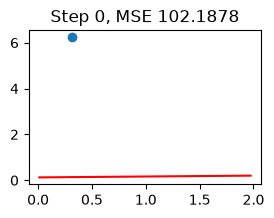

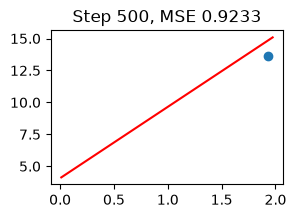

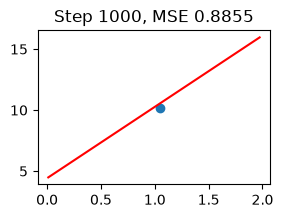

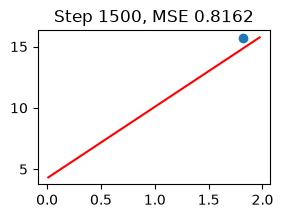

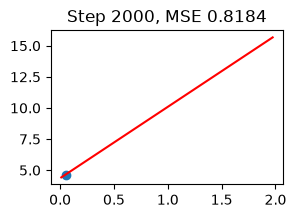

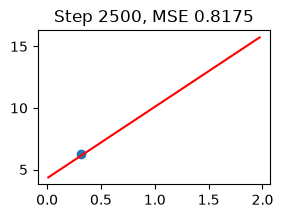

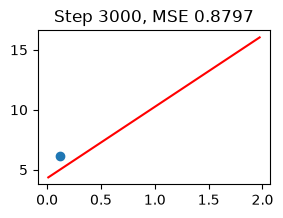

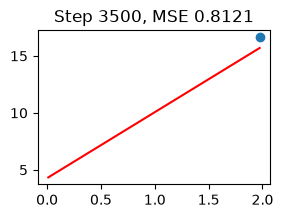

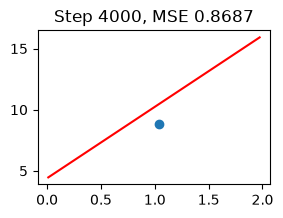

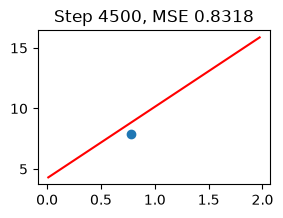

SGD 마지막 w0: 4.1239
SGD 마지막 w1: 5.6115
SGD 마지막 MSE: 0.8731

SGD 최소 MSE step: 2678
SGD 최소 MSE 기준 w0: 4.2154
SGD 최소 MSE 기준 w1: 5.7711
SGD 최소 MSE: 0.8066


In [15]:
def stochastic_gradient_descent(X, y, n_iter=5000, lr=0.01):
    N = len(X)

    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    loss_history = []

    # best_mse: 지금까지 가장 낮았던 MSE를 저장함.
    # np.inf는 무한대 값이므로, 첫 번째 MSE는 무조건 best_mse보다 작아짐.
    best_mse = np.inf
    best_w0 = w0.copy()
    best_w1 = w1.copy()
    best_step = 0

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

    for i in range(n_iter):
        index = np.random.randint(0, N)
        X_i = X[index:index + 1]
        y_i = y[index:index + 1]
        sample_n = len(X_i)

        y_pred_i = w0 + np.dot(X_i, w1)
        diff_i = y_i - y_pred_i

        w0_grad = (-2 / sample_n) * np.sum(diff_i)

        w1_grad = (-2 / sample_n) * np.dot(X_i.T, diff_i)

        w0 -= lr * w0_grad
        w1 -= lr * w1_grad

        y_pred_all = w0 + np.dot(X, w1)
        mse = np.mean((y - y_pred_all) ** 2)
        loss_history.append(mse)

        if mse < best_mse:
            best_mse = mse
            best_w0 = w0.copy()
            best_w1 = w1.copy()
            best_step = i

        if i % 500 == 0:
            plt.figure(figsize=(3, 2))
            plt.scatter(X_i, y_i)
            plt.plot(x_line, w0.item() + w1.item() * x_line, color='r')
            plt.title(f'Step {i}, MSE {mse:.4f}')
            plt.show()

    # 마지막 파라미터와 최소 MSE 기준 파라미터를 함께 반환함.
    return w0, w1, loss_history, best_w0, best_w1, best_mse, best_step

w0_sgd, w1_sgd, loss_history_sgd, best_w0_sgd, best_w1_sgd, best_mse_sgd, best_step_sgd = stochastic_gradient_descent(X, y)

print(f'SGD 마지막 w0: {w0_sgd.item():.4f}')
print(f'SGD 마지막 w1: {w1_sgd.item():.4f}')
print(f'SGD 마지막 MSE: {loss_history_sgd[-1]:.4f}')
print()

print(f'SGD 최소 MSE step: {best_step_sgd}')
print(f'SGD 최소 MSE 기준 w0: {best_w0_sgd.item():.4f}')
print(f'SGD 최소 MSE 기준 w1: {best_w1_sgd.item():.4f}')
print(f'SGD 최소 MSE: {best_mse_sgd:.4f}')

## 최종 정리

- 손실 함수는 모델이 얼마나 틀렸는지 숫자로 계산하는 기준.
- 경사하강법은 손실이 줄어드는 방향으로 파라미터를 반복 수정하는 방법.
- 학습률은 한 번에 움직이는 크기이며, 너무 크거나 작으면 학습이 잘 되지 않을 수 있음.
- Batch GD는 전체 데이터, Mini-batch GD는 일부 묶음, SGD는 데이터 1개로 업데이트함.
- 실제 딥러닝에서는 속도와 안정성의 균형 때문에 Mini-batch 방식이 가장 많이 사용된다.
